# Step 2 — CUDA ESN + Ridge Regression (G1_Dex1_Wipe_Table)

Phase 2 deliverable: train a GPU Echo State Network to bridge **2 Hz VLA target tokens** → **100 Hz G1 joint tracking** on `unitreerobotics/G1_Dex1_Wipe_Table`.

Includes a **hyperparameter sweep** over leaky rate and ridge λ to minimize tracking MSE **and** output jerk (step-to-step chatter).

**Run on:** Lab GPU (NVIDIA Tesla V100 or similar with CUDA).

**Saved artifacts** (under `models/esn_cuda_ridge/`):
- `esn_cuda_ridge_best.pth` — best smoothed model for inference
- `config.json` — hyperparameters + metrics
- `W_out.npy` — readout weights only

CLI equivalent:
```bash
python3 -m src.step2_esn_cuda_ridge --episode 0 --reservoir_size 1000
```

In [1]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    RESEARCH_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "src" / "step2_esn_cuda_ridge.py").is_file():
    RESEARCH_DIR = NOTEBOOK_DIR
else:
    RESEARCH_DIR = NOTEBOOK_DIR / "research_summer_2026" / "research"
    if not RESEARCH_DIR.is_dir():
        RESEARCH_DIR = NOTEBOOK_DIR / "research"

RESEARCH_DIR = RESEARCH_DIR.resolve()
assert (RESEARCH_DIR / "src").is_dir(), f"src package not found under: {RESEARCH_DIR}"

os.chdir(RESEARCH_DIR)
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

print(f"Research root : {RESEARCH_DIR}")
print(f"Models go to  : {RESEARCH_DIR / 'models' / 'esn_cuda_ridge'}")

Research root : /home/aihimekpen/research_summer_2026/research
Models go to  : /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge


In [2]:
# ── Hyperparameters ───────────────────────────────────────────
DATASET_ID = "unitreerobotics/G1_Dex1_Wipe_Table"
EPISODE_INDEX = 0

RESERVOIR_SIZE = 1000
SPECTRAL_RADIUS = 0.95
SPARSITY = 0.90
LEAKY_RATE = 0.1          # default; sweep will search {0.05, 0.1, 0.3}
INPUT_SCALING = 1.0
RIDGE_ALPHA = 1e-2        # default; sweep will search {1e-4, 1e-2, 1.0}
WASHOUT = 50
SEED = 42
DEVICE = "cuda"

RUN_SWEEP = True          # grid search for low MSE + low jerk
JERK_WEIGHT = 1.0         # balance jerk vs MSE in best-model selection

print(f"Dataset  : {DATASET_ID}")
print(f"Episode  : {EPISODE_INDEX}")
print(f"Reservoir: N={RESERVOIR_SIZE} | rho={SPECTRAL_RADIUS} | sparsity={SPARSITY}")
print(f"Defaults : α_leak={LEAKY_RATE} | ridge λ={RIDGE_ALPHA} | sweep={RUN_SWEEP}")

Dataset  : unitreerobotics/G1_Dex1_Wipe_Table
Episode  : 0
Reservoir: N=1000 | rho=0.95 | sparsity=0.9
Defaults : α_leak=0.1 | ridge λ=0.01 | sweep=True


In [3]:
import logging

import torch
from datasets import load_dataset

from src.paths import models_path, results_path
from src.step2_esn_cuda_ridge import (
    BEST_CHECKPOINT_BASENAME,
    CONTROL_HZ,
    VLA_HZ,
    VLA_HOLD_STEPS,
    ESNCudaConfig,
    EchoStateNetwork,
    benchmark_step_hz,
    load_episode_tensors,
    run_hyperparameter_sweep,
    save_checkpoint,
    train_best_esn_from_sweep,
    train_esn_on_episode,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required (target: Tesla V100).")

device = torch.device(DEVICE)
print(f"Device: {device} ({torch.cuda.get_device_name(device)})")

print(f"Loading {DATASET_ID} ...")
dataset = load_dataset(DATASET_ID, split="train")

joint_states, vla_targets = load_episode_tensors(dataset, EPISODE_INDEX, device)
ground_truth = joint_states.clone()
print(
    f"Episode {EPISODE_INDEX}: {joint_states.shape[0]} steps @ {CONTROL_HZ:.0f} Hz "
    f"({joint_states.shape[0] / CONTROL_HZ:.2f} s)"
)

/raid/data/aihimekpen/venvs/research_summer_2026/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda (Tesla V100-DGXS-32GB)
Loading unitreerobotics/G1_Dex1_Wipe_Table ...


Generating train split: 100%|██████████| 75909/75909 [00:00<00:00, 97744.02 examples/s] 


Episode 0: 1231 steps @ 100 Hz (12.31 s)


In [4]:
base_cfg = ESNCudaConfig(
    reservoir_size=RESERVOIR_SIZE,
    spectral_radius=SPECTRAL_RADIUS,
    sparsity=SPARSITY,
    leaky_rate=LEAKY_RATE,
    input_scaling=INPUT_SCALING,
    ridge_alpha=RIDGE_ALPHA,
    washout=WASHOUT,
    seed=SEED,
)

if RUN_SWEEP:
    sweep_df, best_row = run_hyperparameter_sweep(
        base_cfg,
        joint_states,
        vla_targets,
        ground_truth,
        device,
        jerk_weight=JERK_WEIGHT,
    )
    sweep_csv = results_path("step2_training") / "esn_hyperparam_sweep.csv"
    sweep_df.to_csv(sweep_csv, index=False)
    esn, metrics = train_best_esn_from_sweep(
        base_cfg, best_row, joint_states, vla_targets, ground_truth, device,
    )
else:
    sweep_df = None
    esn = EchoStateNetwork(base_cfg, device=device).to(device)
    metrics = train_esn_on_episode(esn, joint_states, vla_targets, ground_truth)

metrics["step_hz"] = benchmark_step_hz(esn, esn.cfg.input_dim)
out_dir = models_path("esn_cuda_ridge")
artifact_paths = save_checkpoint(
    esn,
    metrics,
    out_dir,
    episode_index=EPISODE_INDEX,
    dataset_id=DATASET_ID,
    basename=BEST_CHECKPOINT_BASENAME,
)

print("\n" + "=" * 60)
print("  ESN CUDA Ridge Training — Phase 2 (smoothed)")
print("=" * 60)
print(f"  Dataset episode : {EPISODE_INDEX}")
print(f"  Trajectory steps: {joint_states.shape[0]:,} @ {CONTROL_HZ:.0f} Hz")
print(f"  Best α_leak     : {metrics.get('leaky_rate', esn.cfg.leaky_rate):.2f}")
print(f"  Best ridge λ    : {metrics.get('ridge_alpha', esn.cfg.ridge_alpha):.1e}")
print(f"  Tracking MSE    : {metrics['mse']:.6f}")
print(f"  Tracking RMSE   : {metrics['rmse']:.6f} rad")
print(f"  Output jerk     : {metrics['jerk']:.6f}")
print(f"  GT jerk         : {metrics.get('gt_jerk', float('nan')):.6f}")
print(f"  Jerk ratio      : {metrics.get('jerk_ratio', float('nan')):.2f}x")
print(f"  Step throughput : {metrics['step_hz']:.1f} Hz")
print(f"  Best .pth       : {artifact_paths['pth']}")
if sweep_df is not None:
    print(f"  Sweep CSV       : {sweep_csv}")
    display(sweep_df.sort_values("selection_score").head(5))
print("=" * 60)

2026-07-30 15:42:30,226 [INFO] Hyperparameter sweep | leaky_rate=(0.05, 0.1, 0.3) | ridge_alpha=(0.0001, 0.01, 1.0)
/home/aihimekpen/research_summer_2026/research/src/step2_esn_cuda_ridge.py:283: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return dense.to_sparse_csr()
2026-07-30 15:42:31,567 [INFO]   α_leak=0.05 λ=1.0e-04 → MSE=0.000891 jerk=0.000276
2026-07-30 15:42:31,574 [INFO]   α_leak=0.05 λ=1.0e-02 → MSE=0.000009 jerk=0.000008
2026-07-30 15:42:31,580 [INFO]   α_leak=0.05 λ=1.0e+00 → MSE=0.000005 jerk=0.000005
2026-07-30 15:42:32,448 [INFO]   α_leak=0.10 λ=1.0e-04 → MSE=0.000104 jerk=0.000039
2026-07-30 15:42:32,454 [INFO]   α_leak=0.10 λ=1.0e-02 → MSE=0.003422 jerk=0.001539
2026-07-30 15:42:32,460 [INFO]   α_leak=0.10 λ=1.0e+00 → MSE=0.000003 jerk=0.000005
2026-


  ESN CUDA Ridge Training — Phase 2 (smoothed)
  Dataset episode : 0
  Trajectory steps: 1,231 @ 100 Hz
  Best α_leak     : 0.30
  Best ridge λ    : 1.0e+00
  Tracking MSE    : 0.000001
  Tracking RMSE   : 0.000983 rad
  Output jerk     : 0.000005
  GT jerk         : 0.000005
  Jerk ratio      : 0.98x
  Step throughput : 2885.7 Hz
  Best .pth       : /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge/esn_cuda_ridge_best.pth
  Sweep CSV       : /home/aihimekpen/research_summer_2026/research/results/step2_training/esn_hyperparam_sweep.csv


,leaky_rate,ridge_alpha,mse,rmse,jerk,jerk_rms,selection_score
8,0.30,1.00,9.654129e-07,0.000983,0.000005,346.206744,0.000069
5,0.10,1.00,2.668020e-06,0.001633,0.000005,377.442793,0.000521
2,0.05,1.00,5.341630e-06,0.002311,0.000005,555.073334,0.001279
1,0.05,0.01,8.642115e-06,0.002940,0.000008,4454.931623,0.004454
7,0.30,0.01,9.688728e-05,0.009843,0.000040,11821.588773,0.050711


In [5]:
from src.step2_esn_cuda_ridge import load_checkpoint, predict_from_extended

# Reload best .pth and verify inference-ready deployment.
esn_infer = load_checkpoint(out_dir, device=device)
esn_infer.reset_state()

wo = esn_infer.cfg.washout
reloaded_preds = []
with torch.no_grad():
    for t in range(joint_states.shape[0]):
        esn_infer.update_vla_target(vla_targets[t])
        reloaded_preds.append(esn_infer.step_proprio(joint_states[t]))
reloaded_preds = torch.stack(reloaded_preds, dim=0)

train_preds = predict_from_extended(
    esn.W_out,
    esn.collect_extended_states(joint_states, vla_targets),
)
max_delta = (reloaded_preds[wo:] - train_preds).abs().max().item()

print("Inference checkpoint verification")
print(f"  Reloaded from : {artifact_paths['pth']}")
print(f"  Max |Δ| vs train preds: {max_delta:.2e}")
print(f"  Output jerk   : {metrics['jerk']:.6f} (lower = smoother)")
print(f"  GT jerk       : {metrics.get('gt_jerk', float('nan')):.6f}")
print("  Ready: update_vla_target() @ 2 Hz, step_proprio() @ 100 Hz")

2026-07-30 15:42:35,453 [INFO] Loaded ESN checkpoint from /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge/esn_cuda_ridge_best.pth (v2)
2026-07-30 15:42:35,455 [INFO]   MSE=0.000001 | jerk=0.000005 | step_hz=2885.6689104063307


Inference checkpoint verification
  Reloaded from : /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge/esn_cuda_ridge_best.pth
  Max |Δ| vs train preds: 2.38e-07
  Output jerk   : 0.000005 (lower = smoother)
  GT jerk       : 0.000005
  Ready: update_vla_target() @ 2 Hz, step_proprio() @ 100 Hz


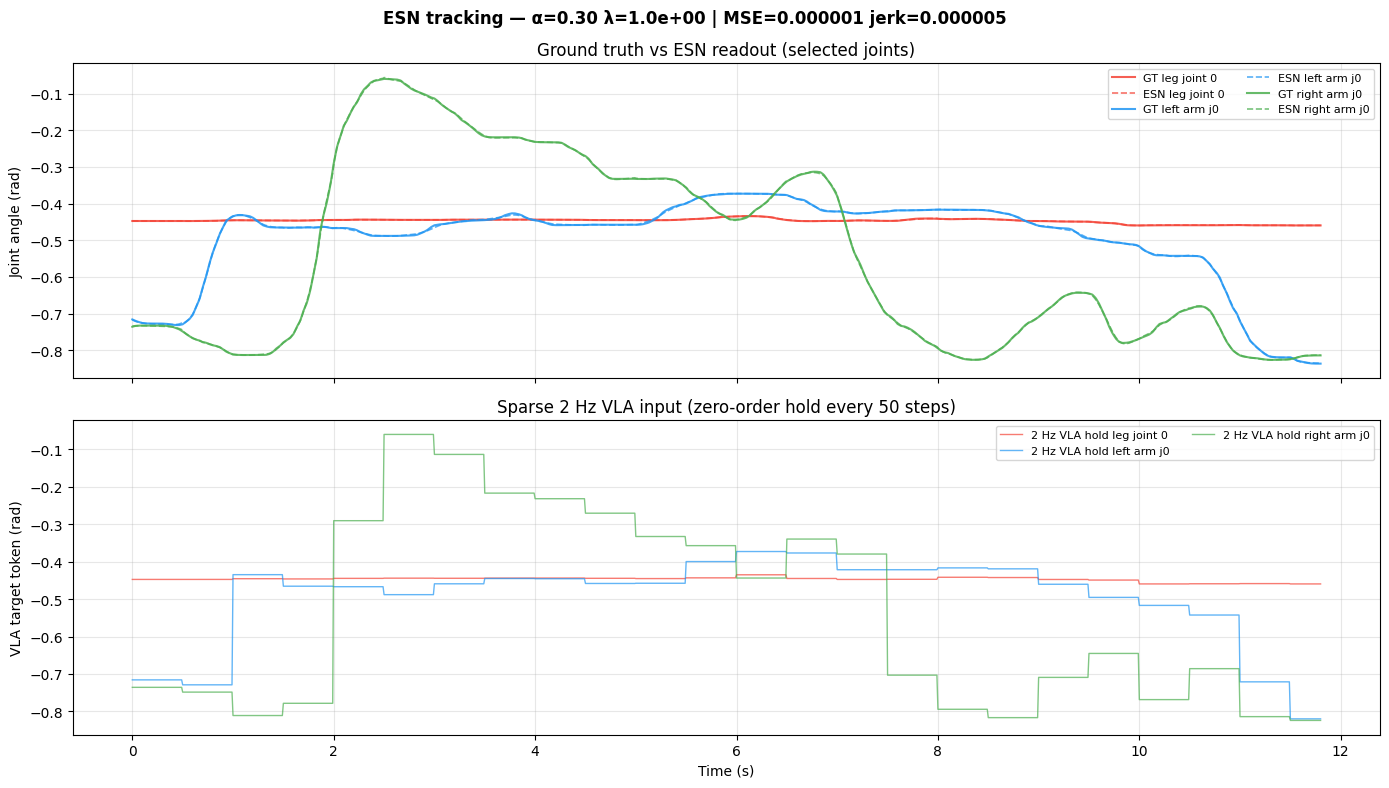

Figure saved: /home/aihimekpen/research_summer_2026/research/results/step2_training/esn_cuda_tracking.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

from src.paths import results_path

wo = esn.cfg.washout
with torch.no_grad():
    states = esn.collect_extended_states(joint_states, vla_targets)
    preds = predict_from_extended(esn.W_out, states).cpu().numpy()

tgt = ground_truth[wo:].cpu().numpy()
t_sec = np.arange(preds.shape[0]) / CONTROL_HZ
joint_ids = [0, 15, 22]  # leg, left arm, right arm
colors = ["#F44336", "#2196F3", "#4CAF50"]
labels = ["leg joint 0", "left arm j0", "right arm j0"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"ESN tracking — α={metrics.get('leaky_rate', esn.cfg.leaky_rate):.2f} "
    f"λ={metrics.get('ridge_alpha', esn.cfg.ridge_alpha):.1e} | "
    f"MSE={metrics['mse']:.6f} jerk={metrics['jerk']:.6f}",
    fontsize=12,
    fontweight="bold",
)

ax = axes[0]
for j, color, label in zip(joint_ids, colors, labels):
    ax.plot(t_sec, tgt[:, j], color=color, lw=1.5, alpha=0.85, label=f"GT {label}")
    ax.plot(t_sec, preds[:, j], color=color, ls="--", lw=1.2, alpha=0.75, label=f"ESN {label}")
ax.set_ylabel("Joint angle (rad)")
ax.set_title("Ground truth vs ESN readout (selected joints)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

ax = axes[1]
vla_cpu = vla_targets[wo:].cpu().numpy()
for j, color, label in zip(joint_ids, colors, labels):
    ax.plot(t_sec, vla_cpu[:, j], color=color, lw=1.0, alpha=0.7, label=f"2 Hz VLA hold {label}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("VLA target token (rad)")
ax.set_title(f"Sparse 2 Hz VLA input (zero-order hold every {VLA_HOLD_STEPS} steps)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
out_dir = results_path("step2_training")
fig.savefig(out_dir / "esn_cuda_tracking.png", dpi=150, bbox_inches="tight")
fig.savefig(out_dir / "esn_cuda_tracking.pdf", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Figure saved: {out_dir / 'esn_cuda_tracking.png'}")